# Task 3 — Explainability

In [1]:
import sys, subprocess, importlib.util, json, re, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Install only packages that are missing in the current Kaggle environment.
required_packages = {
    "torch_geometric": "torch-geometric",
    "shap": "shap",
    "lime": "lime",
}
for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv,
    global_mean_pool, global_max_pool,
)

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


def find_input_file(path_or_name, preferred_tokens=()):
    """
    Accept either:
    - a complete Kaggle path, or
    - just a filename.
    """
    root = Path("/kaggle/input")
    candidate = Path(str(path_or_name))

    # If you supplied a complete path and it exists, use it directly
    if candidate.is_absolute() and candidate.exists():
        return candidate

    # If a relative path exists under /kaggle/input
    if not candidate.is_absolute():
        direct = root / candidate
        if direct.exists():
            return direct

    # Otherwise search using only the filename
    filename = candidate.name
    matches = list(root.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find: {path_or_name}\n"
            f"Also searched /kaggle/input for: {filename}"
        )

    preferred_tokens = tuple(str(x).lower() for x in preferred_tokens)

    scored = []
    for p in matches:
        text = str(p).lower()
        score = sum(token in text for token in preferred_tokens)
        scored.append((score, p))

    scored.sort(key=lambda x: (-x[0], len(str(x[1]))))

    return scored[0][1]

    preferred_tokens = tuple(str(t).lower() for t in preferred_tokens)
    scored = []
    for p in matches:
        text = str(p).lower()
        score = sum(token in text for token in preferred_tokens)
        scored.append((score, p))

    scored.sort(key=lambda x: (-x[0], len(str(x[1]))))
    best_score = scored[0][0]
    best = [p for score, p in scored if score == best_score]

    if len(best) > 1 and best_score == 0:
        print(f"Warning: multiple {filename} files found. Using: {best[0]}")
    return best[0]


MODEL_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/task3-improvemnent-models/final_gnn_model.pth")
PREPROCESS_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/task3-improvemnent-models/final_gnn_preprocessing.joblib")
PREDICTIONS_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/task-3-results/final_gnn_test_predictions.csv")
FINAL_CONFIG_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/task-3-results/final_config.json")
FEATURE_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/putemg-window-feature-dataset-parquet/putemg_window_feature_dataset.parquet")
SPLIT_PATH = find_input_file("/kaggle/input/datasets/tahminaahmed151/task2-baseline-result/split_info.json")

OUTPUT_FOLDER = Path("/kaggle/working/task3_xai_results")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

print("\nResolved inputs:")
for name, path in {
    "Model": MODEL_PATH,
    "Preprocessing": PREPROCESS_PATH,
    "Predictions": PREDICTIONS_PATH,
    "Final config": FINAL_CONFIG_PATH,
    "Feature dataset": FEATURE_PATH,
    "Split info": SPLIT_PATH,
}.items():
    print(f"{name:15s}: {path}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.3 MB/s eta 0:00:00
Device: cuda

Resolved inputs:
Model          : /kaggle/input/datasets/tahminaahmed151/task3-improvemnent-models/final_gnn_model.pth
Preprocessing  : /kaggle/input/datasets/tahminaahmed151/task3-improvemnent-models/final_gnn_preprocessing.joblib
Predictions    : /kaggle/input/datasets/tahminaahmed151/task-3-results/final_gnn_test_predictions.csv
Final config   : /kaggle/input/datasets/tahminaahmed151/task-3-results/final_config.json
Feature dataset: /kaggle/input/datasets/tahminaahmed151/putemg-window-feature-dataset-parquet/putemg_window_feature_dataset.parquet
Split info     : /kaggle/input/datasets/tahminaahmed151/task2-baseline-result/split_info.json


## Section 2 — Load and verify the frozen final model artifacts

The model architecture is reconstructed from the configuration saved by the improvement notebook.  
No graph or preprocessing step is re-fitted.

In [2]:
GESTURE_NAMES = {
    0: "Idle",
    1: "Fist",
    2: "Flexion",
    3: "Extension",
    6: "Pinch-Index",
    7: "Pinch-Middle",
    8: "Pinch-Ring",
    9: "Pinch-Small",
}

# PyTorch 2.6+ may default to weights_only=True.
# This is our own trusted Task-3 checkpoint and contains configuration/NumPy metadata.
checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)
preprocessing = joblib.load(PREPROCESS_PATH)

with open(FINAL_CONFIG_PATH, "r") as f:
    final_config_file = json.load(f)

required_checkpoint_keys = {
    "model_state",
    "config",
    "edge_index",
    "edge_weight",
    "feat_cols",
    "n_channels",
    "n_metrics",
    "label_classes",
}
missing = required_checkpoint_keys - set(checkpoint)
assert not missing, f"Checkpoint missing keys: {sorted(missing)}"

required_preprocess_keys = {
    "variance_threshold",
    "robust_scaler",
    "label_encoder",
    "feat_cols",
}
missing = required_preprocess_keys - set(preprocessing)
assert not missing, f"Preprocessing artifact missing keys: {sorted(missing)}"

final_config = checkpoint["config"]
assert final_config == final_config_file, (
    "final_config.json does not match the configuration embedded in the model checkpoint."
)

feat_cols = list(checkpoint["feat_cols"])
assert feat_cols == list(preprocessing["feat_cols"])
assert len(feat_cols) == 168

N_CHANNELS = int(checkpoint["n_channels"])
N_METRICS = int(checkpoint["n_metrics"])
assert N_CHANNELS == 24
assert N_METRICS == 7
assert len(feat_cols) == N_CHANNELS * N_METRICS

label_classes = [int(x) for x in checkpoint["label_classes"]]
class_names = [GESTURE_NAMES[x] for x in label_classes]

vt = preprocessing["variance_threshold"]
scaler = preprocessing["robust_scaler"]
le = preprocessing["label_encoder"]

assert [int(x) for x in le.classes_] == label_classes

edge_index = checkpoint["edge_index"].long().cpu()
edge_weight = checkpoint["edge_weight"].float().cpu()

print("Frozen final configuration:")
for k, v in final_config.items():
    print(f"  {k:20s}: {v}")

print("\nClasses:", class_names)
print("Input features:", len(feat_cols))
print("Graph directed PyG entries:", edge_index.shape[1])

Frozen final configuration:
  graph_method        : topk
  top_k               : 2
  edge_weight_mode    : binary
  variant             : sage
  hidden_dims         : [64, 128, 128]
  dropout             : 0.3
  use_batchnorm       : True
  pooling             : mean_max
  optimizer           : adamw
  scheduler           : plateau
  lr                  : 0.001
  weight_decay        : 0.0001
  epochs              : 100
  patience            : 10
  use_class_weight    : False
  batch_size          : 512

Classes: ['Idle', 'Fist', 'Flexion', 'Extension', 'Pinch-Index', 'Pinch-Middle', 'Pinch-Ring', 'Pinch-Small']
Input features: 168
Graph directed PyG entries: 72


## Section 3 — Reconstruct the exact `FlexGNN` architecture and load weights

This is the same flexible GNN definition used by the Task-3 improvement notebook.  
For GraphSAGE, edge weights are not consumed by `SAGEConv`; for GCN/GAT, the saved edge weights are used exactly as in training.

In [3]:
class FlexGNN(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dims,
        n_classes,
        variant="gcn",
        dropout=0.3,
        use_batchnorm=True,
        pooling="mean_max",
        gat_heads=4,
    ):
        super().__init__()
        assert variant in ("gcn", "gat", "sage")
        assert pooling in ("mean_max", "mean", "max")

        self.variant = variant
        self.pooling = pooling
        self.dropout = dropout
        self.use_batchnorm = use_batchnorm

        dims = [in_dim] + list(hidden_dims)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for d_in, d_out in zip(dims[:-1], dims[1:]):
            if variant == "gcn":
                self.convs.append(GCNConv(d_in, d_out))
            elif variant == "gat":
                self.convs.append(
                    GATConv(
                        d_in,
                        d_out,
                        heads=gat_heads,
                        concat=False,
                        edge_dim=1,
                    )
                )
            else:
                self.convs.append(SAGEConv(d_in, d_out))

            self.bns.append(
                nn.BatchNorm1d(d_out) if use_batchnorm else nn.Identity()
            )

        last_dim = dims[-1]
        pooled_dim = last_dim * 2 if pooling == "mean_max" else last_dim

        self.fc1 = nn.Linear(pooled_dim, 128)
        self.fc_mid = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def _conv_forward(self, conv, x, edge_index, edge_weight):
        if self.variant == "gcn":
            return conv(x, edge_index, edge_weight=edge_weight)
        elif self.variant == "gat":
            edge_attr = (
                edge_weight.unsqueeze(1)
                if edge_weight is not None
                else None
            )
            return conv(x, edge_index, edge_attr=edge_attr)
        else:
            return conv(x, edge_index)

    def forward(self, x, edge_index, edge_weight, batch):
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            x = self._conv_forward(conv, x, edge_index, edge_weight)
            x = bn(x)
            x = F.relu(x)
            if i < len(self.convs) - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        if self.pooling == "mean_max":
            x = torch.cat(
                [
                    global_mean_pool(x, batch),
                    global_max_pool(x, batch),
                ],
                dim=1,
            )
        elif self.pooling == "mean":
            x = global_mean_pool(x, batch)
        else:
            x = global_max_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc_mid(x))
        x = F.dropout(x, p=self.dropout, training=self.training)

        return F.log_softmax(self.fc2(x), dim=1)


model = FlexGNN(
    in_dim=N_METRICS,
    hidden_dims=final_config.get("hidden_dims", [64, 128]),
    n_classes=len(label_classes),
    variant=final_config.get("variant", "gcn"),
    dropout=final_config.get("dropout", 0.3),
    use_batchnorm=final_config.get("use_batchnorm", True),
    pooling=final_config.get("pooling", "mean_max"),
    gat_heads=final_config.get("gat_heads", 4),
).to(device)

model.load_state_dict(checkpoint["model_state"])
model.eval()

edge_index_device = edge_index.to(device)
edge_weight_device = edge_weight.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded final {final_config.get('variant', 'gcn').upper()} model")
print(f"Parameters: {n_params:,}")

Loaded final SAGE model
Parameters: 92,680


## Section 4 — Reconstruct the frozen test set and verify saved predictions

The exact Task-2 test subjects are loaded from `split_info.json`.  
The row ordering is reconstructed exactly as in the improvement notebook and checked against `final_gnn_test_predictions.csv`.

In [4]:
feature_df = pd.read_parquet(FEATURE_PATH)

with open(SPLIT_PATH, "r") as f:
    split_info = json.load(f)

required_split_keys = {
    "train_subjects",
    "val_subjects",
    "test_subjects",
    "feat_cols",
    "label_classes",
}
missing = required_split_keys - set(split_info)
assert not missing, f"split_info.json missing keys: {sorted(missing)}"

train_subjects = [int(x) for x in split_info["train_subjects"]]
val_subjects = [int(x) for x in split_info["val_subjects"]]
test_subjects = [int(x) for x in split_info["test_subjects"]]

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

test_df = (
    feature_df[feature_df["subject_id"].isin(test_subjects)]
    .copy()
    .reset_index(drop=True)
)

predictions_df = pd.read_csv(PREDICTIONS_PATH)

assert len(test_df) == len(predictions_df)
assert np.array_equal(
    predictions_df["row_index_in_test_df"].to_numpy(),
    np.arange(len(test_df)),
)
assert np.array_equal(
    predictions_df["subject_id"].astype(int).to_numpy(),
    test_df["subject_id"].astype(int).to_numpy(),
)
assert np.array_equal(
    predictions_df["true_label"].astype(int).to_numpy(),
    test_df["label"].astype(int).to_numpy(),
)

proba_cols = [c for c in predictions_df.columns if c.startswith("proba_")]
assert len(proba_cols) == len(label_classes)
predictions_df["prediction_confidence"] = predictions_df[proba_cols].max(axis=1)

print(f"Frozen test subjects: {test_subjects}")
print(f"Frozen test windows : {len(test_df):,}")
print(f"Correct predictions : {int(predictions_df['correct'].sum()):,}")
print(f"Wrong predictions   : {int((~predictions_df['correct'].astype(bool)).sum()):,}")

Frozen test subjects: [24, 50, 30, 34, 51, 7, 54]
Frozen test windows : 98,405
Correct predictions : 72,374
Wrong predictions   : 26,031


## Section 5 — Select one correct and one wrong sample without cherry-picking

To avoid selecting only extreme/easy examples, the notebook chooses the sample whose prediction confidence is **closest to the median confidence** within:

- all correctly classified test windows
- all incorrectly classified test windows

This gives a deterministic representative correct case and a representative error case.

In [5]:
predictions_df["correct"] = predictions_df["correct"].astype(bool)

def select_median_confidence_sample(df, correct_value):
    subset = df[df["correct"] == correct_value].copy()
    assert len(subset) > 0, (
        "No sample exists for the requested correctness group."
    )
    median_conf = subset["prediction_confidence"].median()
    selected_idx = (
        subset["prediction_confidence"]
        .sub(median_conf)
        .abs()
        .idxmin()
    )
    return df.loc[selected_idx].copy()

correct_record = select_median_confidence_sample(predictions_df, True)
wrong_record = select_median_confidence_sample(predictions_df, False)

selected_records = pd.DataFrame([
    {
        "Case": "Correct",
        "row_index_in_test_df": int(correct_record["row_index_in_test_df"]),
        "subject_id": int(correct_record["subject_id"]),
        "true_label": int(correct_record["true_label"]),
        "true_class": GESTURE_NAMES[int(correct_record["true_label"])],
        "pred_label": int(correct_record["pred_label"]),
        "pred_class": GESTURE_NAMES[int(correct_record["pred_label"])],
        "prediction_confidence": float(correct_record["prediction_confidence"]),
    },
    {
        "Case": "Wrong",
        "row_index_in_test_df": int(wrong_record["row_index_in_test_df"]),
        "subject_id": int(wrong_record["subject_id"]),
        "true_label": int(wrong_record["true_label"]),
        "true_class": GESTURE_NAMES[int(wrong_record["true_label"])],
        "pred_label": int(wrong_record["pred_label"]),
        "pred_class": GESTURE_NAMES[int(wrong_record["pred_label"])],
        "prediction_confidence": float(wrong_record["prediction_confidence"]),
    },
])

display(selected_records)
selected_records.to_csv(
    OUTPUT_FOLDER / "selected_xai_samples.csv",
    index=False,
)

,Case,row_index_in_test_df,subject_id,true_label,true_class,pred_label,pred_class,prediction_confidence
0,Correct,67858,50,8,Pinch-Ring,8,Pinch-Ring,0.919520
1,Wrong,62877,50,2,Flexion,1,Fist,0.571337


## Section 6 — Apply the saved preprocessing and define a frozen-model probability wrapper

SHAP and LIME perturb the **168 scaled input features** while the learned graph and GNN parameters stay frozen.

The wrapper converts each perturbed 168-feature vector back into the exact `24 electrodes × 7 features` node representation used by the final model.

In [6]:
def transform_raw_features(df):
    X_raw = df[feat_cols].to_numpy(dtype="float32")
    assert np.isfinite(X_raw).all()

    X_vt = vt.transform(X_raw)
    X_scaled = scaler.transform(X_vt).astype("float32")

    assert X_scaled.shape[1] == N_CHANNELS * N_METRICS
    assert np.isfinite(X_scaled).all()
    return X_scaled


def to_node_features(X_scaled):
    # Exact Task-3 conversion:
    # metric-major 168 -> (n, 7, 24) -> (n, 24, 7)
    return (
        X_scaled
        .reshape(-1, N_METRICS, N_CHANNELS)
        .transpose(0, 2, 1)
    )


def predict_proba_scaled(X_scaled, batch_size=256):
    """Probability predictions for SHAP/LIME in already-scaled feature space."""
    X_scaled = np.asarray(X_scaled, dtype="float32")
    if X_scaled.ndim == 1:
        X_scaled = X_scaled.reshape(1, -1)

    assert X_scaled.shape[1] == len(feat_cols)
    X_nodes = to_node_features(X_scaled)

    edge_attr = edge_weight.unsqueeze(1)
    data_list = [
        Data(
            x=torch.tensor(X_nodes[i], dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=edge_attr,
        )
        for i in range(len(X_nodes))
    ]

    loader = PyGLoader(
        data_list,
        batch_size=batch_size,
        shuffle=False,
    )

    probs = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            log_probs = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch,
            )
            probs.append(torch.exp(log_probs).cpu().numpy())

    return np.concatenate(probs, axis=0)


correct_row = int(correct_record["row_index_in_test_df"])
wrong_row = int(wrong_record["row_index_in_test_df"])

selected_test_df = test_df.iloc[[correct_row, wrong_row]].copy()
X_selected = transform_raw_features(selected_test_df)

selected_probs = predict_proba_scaled(X_selected)
selected_pred_encoded = selected_probs.argmax(axis=1)
selected_pred_labels = le.inverse_transform(selected_pred_encoded)

assert int(selected_pred_labels[0]) == int(correct_record["pred_label"])
assert int(selected_pred_labels[1]) == int(wrong_record["pred_label"])

print("Frozen-model prediction check passed for both selected samples.")

Frozen-model prediction check passed for both selected samples.


## Section 7 — Build training-only reference data for SHAP and LIME

The explanation reference distribution is sampled only from the original **31 Task-2 training subjects**.

A stratified sample is used so all eight gesture classes are represented:
- SHAP background: small training-only sample for computational efficiency
- LIME reference: larger training-only sample for perturbation statistics

No test sample is used as an explainer background.

In [7]:
train_df = (
    feature_df[feature_df["subject_id"].isin(train_subjects)]
    .copy()
    .reset_index(drop=True)
)

def stratified_rows(df, per_class, seed):
    parts = []
    for label_value in sorted(df["label"].unique()):
        group = df[df["label"] == label_value]
        n = min(int(per_class), len(group))
        parts.append(group.sample(n=n, random_state=seed + int(label_value)))
    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )

# 3 per class = 24 SHAP background windows.
shap_background_df = stratified_rows(
    train_df,
    per_class=3,
    seed=RANDOM_STATE,
)

# 200 per class = up to 1,600 LIME reference windows.
lime_reference_df = stratified_rows(
    train_df,
    per_class=200,
    seed=RANDOM_STATE + 100,
)

X_shap_background = transform_raw_features(shap_background_df)
X_lime_reference = transform_raw_features(lime_reference_df)

print("SHAP background:", X_shap_background.shape)
print("LIME reference :", X_lime_reference.shape)
print("Both reference sets use training subjects only.")

SHAP background: (24, 168)
LIME reference : (1600, 168)
Both reference sets use training subjects only.


# SHAP

## Section 8 — Permutation SHAP for the correct and wrong samples

We use model-agnostic **Permutation SHAP** because the frozen predictor is a PyTorch-Geometric GNN rather than a plain tabular neural network.

The explainer perturbs the 168 input features while holding the saved graph topology fixed.  
For each sample, the notebook explains the probability of the model's **predicted class**.

In [8]:
# Independent masker uses only training-subject reference windows.
masker = shap.maskers.Independent(
    X_shap_background,
    max_samples=len(X_shap_background),
)

shap_explainer = shap.Explainer(
    predict_proba_scaled,
    masker,
    algorithm="permutation",
    output_names=class_names,
)

# Minimum is 2 * n_features + 1.
# Two full permutation passes provide a compact but non-trivial local explanation.
SHAP_MAX_EVALS = 2 * (2 * len(feat_cols) + 1)

print("Running SHAP. This may take several minutes...")
shap_explanation = shap_explainer(
    X_selected,
    max_evals=SHAP_MAX_EVALS,
    batch_size=128,
)

print("SHAP complete.")
print("SHAP values shape:", np.asarray(shap_explanation.values).shape)

Running SHAP. This may take several minutes...
SHAP complete.
SHAP values shape: (2, 168, 8)


## Section 9 — Convert SHAP values into report-ready feature/electrode/metric tables

In [9]:
FEATURE_RE = re.compile(
    r"^EMG_(\d+)_(MAV|RMS|STD|VAR|WL|ZC|SSC)$",
    re.I,
)

def parse_feature_name(name):
    m = FEATURE_RE.fullmatch(str(name))
    if m is None:
        raise ValueError(f"Unexpected feature name: {name}")
    return int(m.group(1)), m.group(2).upper()


def attribution_table(values, method, case_name):
    values = np.asarray(values, dtype=float).reshape(-1)
    assert len(values) == len(feat_cols)

    rows = []
    for feature, value in zip(feat_cols, values):
        electrode, metric = parse_feature_name(feature)
        rows.append({
            "Case": case_name,
            "Method": method,
            "Feature": feature,
            "Electrode": electrode,
            "Metric": metric,
            "Attribution": float(value),
            "Absolute attribution": float(abs(value)),
        })
    return pd.DataFrame(rows)


def extract_shap_for_class(explanation, sample_index, class_index):
    values = np.asarray(explanation.values)

    # Standard multi-output shape: (samples, features, classes)
    if values.ndim == 3:
        return values[sample_index, :, class_index]

    # Single-output fallback.
    if values.ndim == 2:
        return values[sample_index, :]

    raise ValueError(f"Unexpected SHAP values shape: {values.shape}")


correct_pred_idx = int(le.transform([int(correct_record["pred_label"])])[0])
wrong_pred_idx = int(le.transform([int(wrong_record["pred_label"])])[0])

shap_correct_values = extract_shap_for_class(
    shap_explanation,
    sample_index=0,
    class_index=correct_pred_idx,
)
shap_wrong_values = extract_shap_for_class(
    shap_explanation,
    sample_index=1,
    class_index=wrong_pred_idx,
)

shap_correct_df = attribution_table(
    shap_correct_values,
    "SHAP",
    "Correct",
)
shap_wrong_df = attribution_table(
    shap_wrong_values,
    "SHAP",
    "Wrong",
)

shap_all_df = pd.concat(
    [shap_correct_df, shap_wrong_df],
    ignore_index=True,
)

shap_all_df.to_csv(
    OUTPUT_FOLDER / "shap_feature_attributions.csv",
    index=False,
)

print("Top SHAP features — correct sample:")
display(
    shap_correct_df
    .sort_values("Absolute attribution", ascending=False)
    .head(15)
)

print("\nTop SHAP features — wrong sample:")
display(
    shap_wrong_df
    .sort_values("Absolute attribution", ascending=False)
    .head(15)
)

Top SHAP features — correct sample:


,Case,Method,Feature,Electrode,Metric,Attribution,Absolute attribution
117,Correct,SHAP,EMG_22_WL,22,WL,0.184355,0.184355
108,Correct,SHAP,EMG_13_WL,13,WL,0.135368,0.135368
57,Correct,SHAP,EMG_10_STD,10,STD,0.120332,0.120332
115,Correct,SHAP,EMG_20_WL,20,WL,0.085339,0.085339
58,Correct,SHAP,EMG_11_STD,11,STD,0.075591,0.075591
98,Correct,SHAP,EMG_3_WL,3,WL,0.064677,0.064677
69,Correct,SHAP,EMG_22_STD,22,STD,0.048630,0.048630
109,Correct,SHAP,EMG_14_WL,14,WL,0.037260,0.037260
119,Correct,SHAP,EMG_24_WL,24,WL,0.032177,0.032177
21,Correct,SHAP,EMG_22_MAV,22,MAV,0.031710,0.031710



Top SHAP features — wrong sample:


,Case,Method,Feature,Electrode,Metric,Attribution,Absolute attribution
109,Wrong,SHAP,EMG_14_WL,14,WL,0.134081,0.134081
101,Wrong,SHAP,EMG_6_WL,6,WL,0.076216,0.076216
98,Wrong,SHAP,EMG_3_WL,3,WL,-0.068284,0.068284
116,Wrong,SHAP,EMG_21_WL,21,WL,0.045388,0.045388
106,Wrong,SHAP,EMG_11_WL,11,WL,-0.038753,0.038753
107,Wrong,SHAP,EMG_12_WL,12,WL,-0.038185,0.038185
114,Wrong,SHAP,EMG_19_WL,19,WL,0.037851,0.037851
37,Wrong,SHAP,EMG_14_RMS,14,RMS,0.035833,0.035833
108,Wrong,SHAP,EMG_13_WL,13,WL,0.035297,0.035297
115,Wrong,SHAP,EMG_20_WL,20,WL,-0.030206,0.030206


## Section 10 — SHAP visualizations

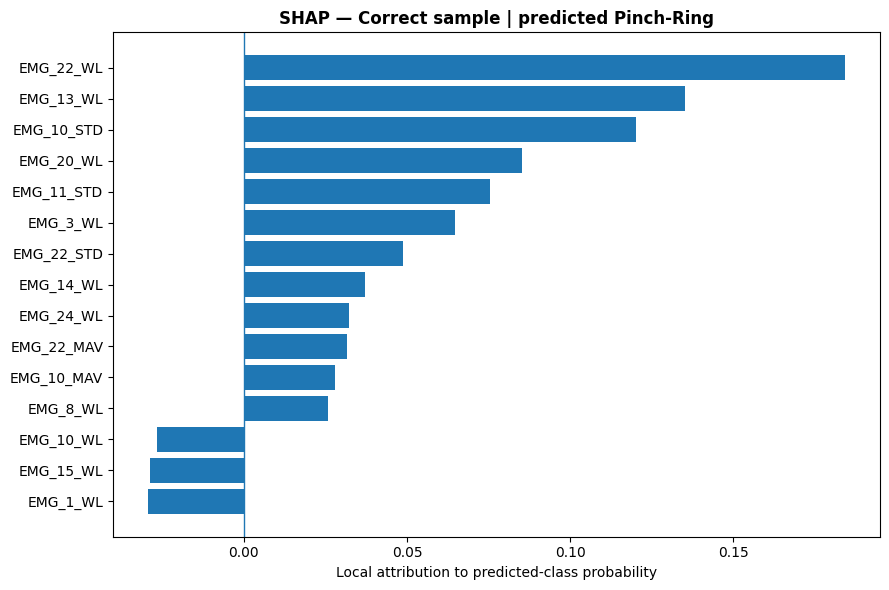

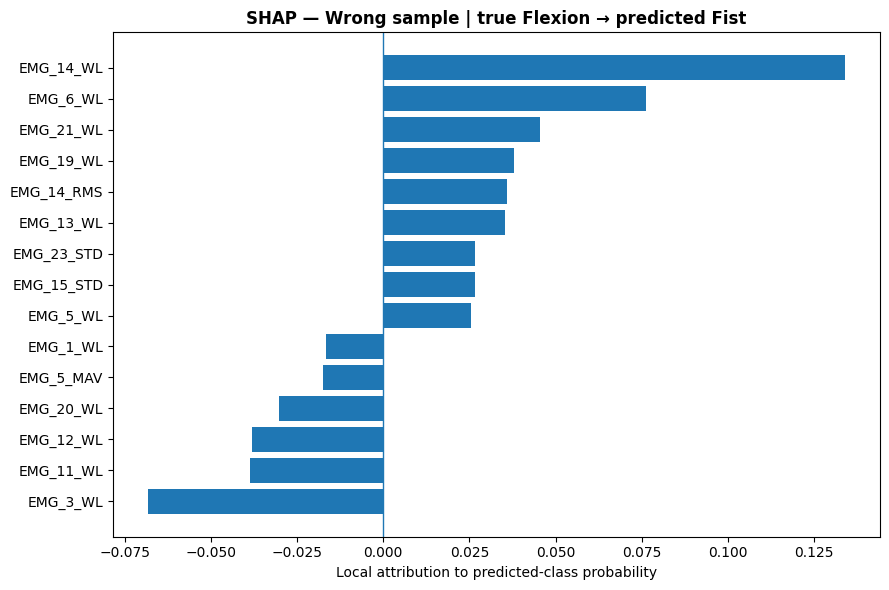

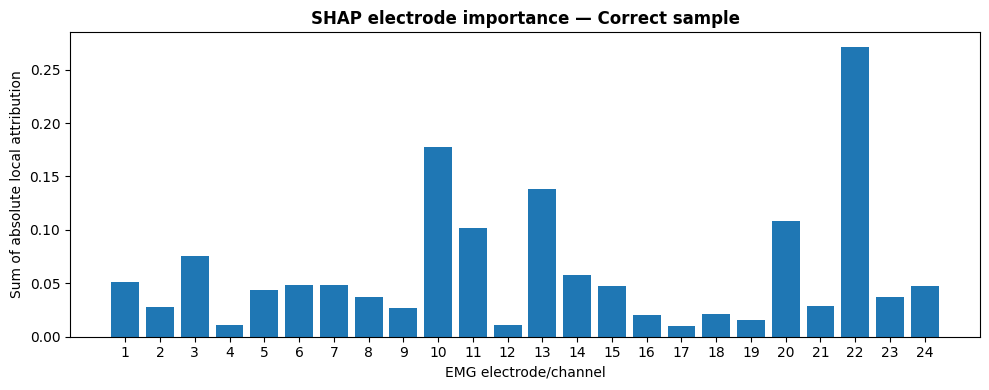

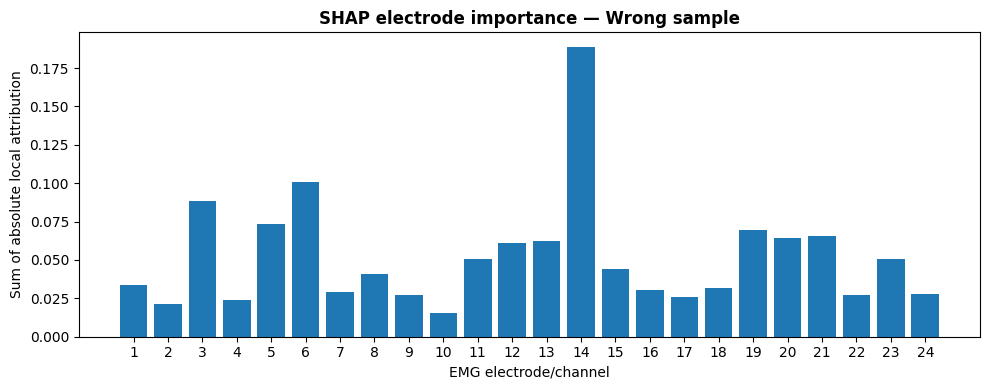

In [10]:
def plot_top_attributions(df, title, filename, top_n=15):
    top = (
        df.sort_values("Absolute attribution", ascending=False)
        .head(top_n)
        .sort_values("Attribution")
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top["Feature"], top["Attribution"])
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Local attribution to predicted-class probability")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUTPUT_FOLDER / filename, dpi=200, bbox_inches="tight")
    plt.show()


def plot_electrode_importance(df, title, filename):
    electrode_df = (
        df.groupby("Electrode", as_index=False)["Absolute attribution"]
        .sum()
        .sort_values("Electrode")
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(electrode_df["Electrode"], electrode_df["Absolute attribution"])
    ax.set_xlabel("EMG electrode/channel")
    ax.set_ylabel("Sum of absolute local attribution")
    ax.set_xticks(range(1, N_CHANNELS + 1))
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUTPUT_FOLDER / filename, dpi=200, bbox_inches="tight")
    plt.show()


plot_top_attributions(
    shap_correct_df,
    f"SHAP — Correct sample | predicted {GESTURE_NAMES[int(correct_record['pred_label'])]}",
    "shap_correct_top_features.png",
)
plot_top_attributions(
    shap_wrong_df,
    (
        f"SHAP — Wrong sample | true {GESTURE_NAMES[int(wrong_record['true_label'])]} "
        f"→ predicted {GESTURE_NAMES[int(wrong_record['pred_label'])]}"
    ),
    "shap_wrong_top_features.png",
)

plot_electrode_importance(
    shap_correct_df,
    "SHAP electrode importance — Correct sample",
    "shap_correct_electrodes.png",
)
plot_electrode_importance(
    shap_wrong_df,
    "SHAP electrode importance — Wrong sample",
    "shap_wrong_electrodes.png",
)

# LIME

## Section 11 — LIME explanations for the same two frozen test samples

LIME uses the training-only scaled reference data to generate local perturbations.  
As with SHAP, the explanation target is the model's **predicted class**.

In [11]:
lime_explainer = LimeTabularExplainer(
    training_data=X_lime_reference,
    feature_names=feat_cols,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

LIME_NUM_FEATURES = 20
LIME_NUM_SAMPLES = 2000

print("Running LIME for correct sample...")
lime_correct_exp = lime_explainer.explain_instance(
    X_selected[0],
    predict_proba_scaled,
    labels=(correct_pred_idx,),
    num_features=LIME_NUM_FEATURES,
    num_samples=LIME_NUM_SAMPLES,
)

print("Running LIME for wrong sample...")
lime_wrong_exp = lime_explainer.explain_instance(
    X_selected[1],
    predict_proba_scaled,
    labels=(wrong_pred_idx,),
    num_features=LIME_NUM_FEATURES,
    num_samples=LIME_NUM_SAMPLES,
)

print("LIME complete.")

Running LIME for correct sample...
Running LIME for wrong sample...
LIME complete.


## Section 12 — Convert LIME explanations into the same feature/electrode/metric format

In [12]:
def lime_full_vector(exp, class_index, n_features):
    values = np.zeros(n_features, dtype=float)
    explanation_map = exp.as_map()
    assert class_index in explanation_map, (
        f"LIME explanation does not contain class index {class_index}"
    )
    for feature_idx, weight in explanation_map[class_index]:
        values[int(feature_idx)] = float(weight)
    return values


lime_correct_values = lime_full_vector(
    lime_correct_exp,
    correct_pred_idx,
    len(feat_cols),
)
lime_wrong_values = lime_full_vector(
    lime_wrong_exp,
    wrong_pred_idx,
    len(feat_cols),
)

lime_correct_df = attribution_table(
    lime_correct_values,
    "LIME",
    "Correct",
)
lime_wrong_df = attribution_table(
    lime_wrong_values,
    "LIME",
    "Wrong",
)

lime_all_df = pd.concat(
    [lime_correct_df, lime_wrong_df],
    ignore_index=True,
)

lime_all_df.to_csv(
    OUTPUT_FOLDER / "lime_feature_attributions.csv",
    index=False,
)

print("Top LIME features — correct sample:")
display(
    lime_correct_df
    .sort_values("Absolute attribution", ascending=False)
    .head(15)
)

print("\nTop LIME features — wrong sample:")
display(
    lime_wrong_df
    .sort_values("Absolute attribution", ascending=False)
    .head(15)
)

Top LIME features — correct sample:


,Case,Method,Feature,Electrode,Metric,Attribution,Absolute attribution
113,Correct,LIME,EMG_18_WL,18,WL,0.005284,0.005284
10,Correct,LIME,EMG_11_MAV,11,MAV,0.004900,0.004900
97,Correct,LIME,EMG_2_WL,2,WL,0.004891,0.004891
37,Correct,LIME,EMG_14_RMS,14,RMS,0.004885,0.004885
21,Correct,LIME,EMG_22_MAV,22,MAV,0.004689,0.004689
32,Correct,LIME,EMG_9_RMS,9,RMS,0.004619,0.004619
159,Correct,LIME,EMG_16_SSC,16,SSC,0.004615,0.004615
76,Correct,LIME,EMG_5_VAR,5,VAR,0.004518,0.004518
14,Correct,LIME,EMG_15_MAV,15,MAV,0.004394,0.004394
148,Correct,LIME,EMG_5_SSC,5,SSC,0.004385,0.004385



Top LIME features — wrong sample:


,Case,Method,Feature,Electrode,Metric,Attribution,Absolute attribution
130,Wrong,LIME,EMG_11_ZC,11,ZC,0.007927,0.007927
88,Wrong,LIME,EMG_17_VAR,17,VAR,0.007055,0.007055
149,Wrong,LIME,EMG_6_SSC,6,SSC,0.007039,0.007039
131,Wrong,LIME,EMG_12_ZC,12,ZC,0.007020,0.007020
80,Wrong,LIME,EMG_9_VAR,9,VAR,0.006477,0.006477
24,Wrong,LIME,EMG_1_RMS,1,RMS,0.006398,0.006398
76,Wrong,LIME,EMG_5_VAR,5,VAR,0.006018,0.006018
101,Wrong,LIME,EMG_6_WL,6,WL,0.005898,0.005898
96,Wrong,LIME,EMG_1_WL,1,WL,0.005776,0.005776
144,Wrong,LIME,EMG_1_SSC,1,SSC,0.005630,0.005630


## Section 13 — LIME visualizations

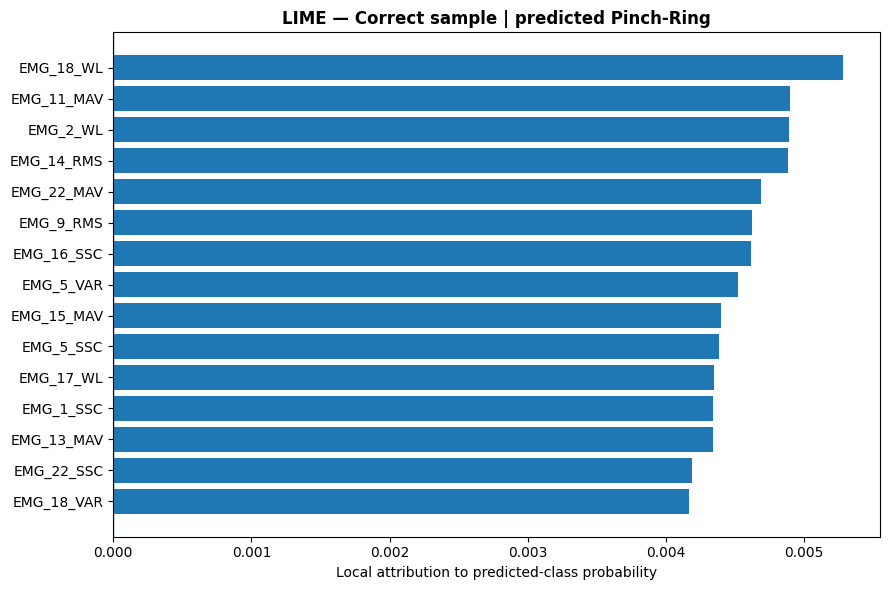

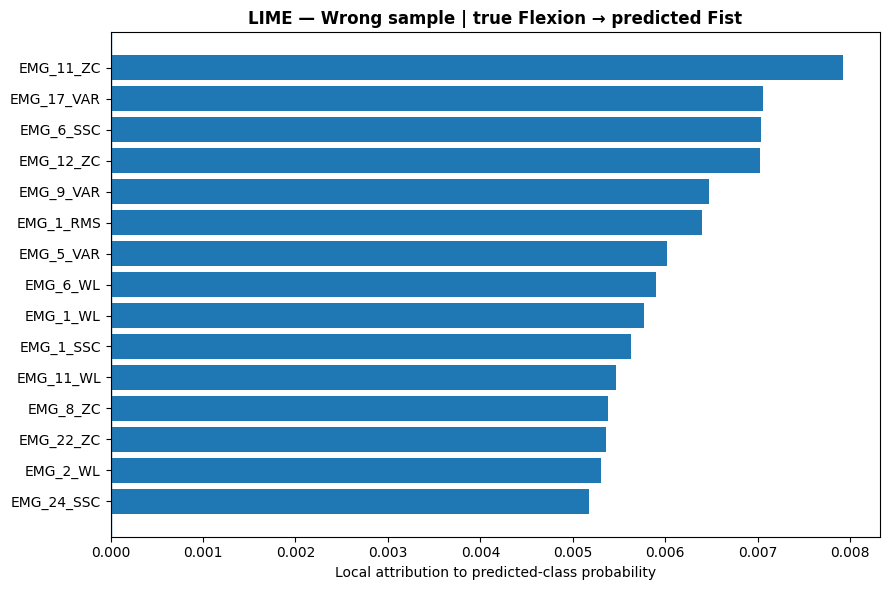

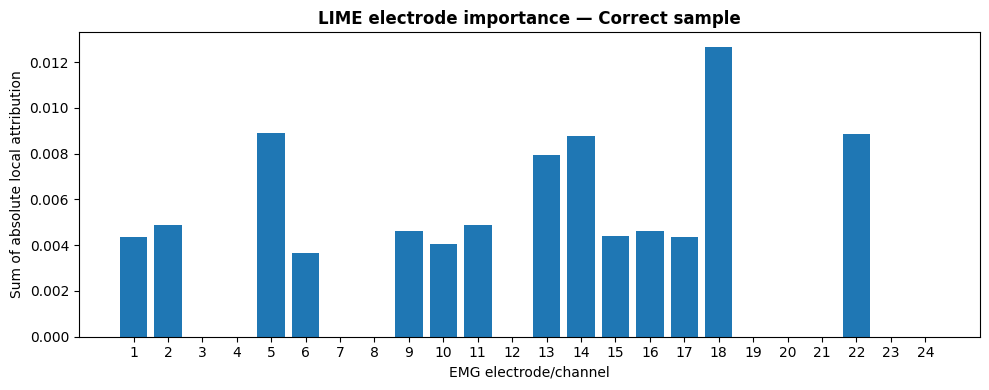

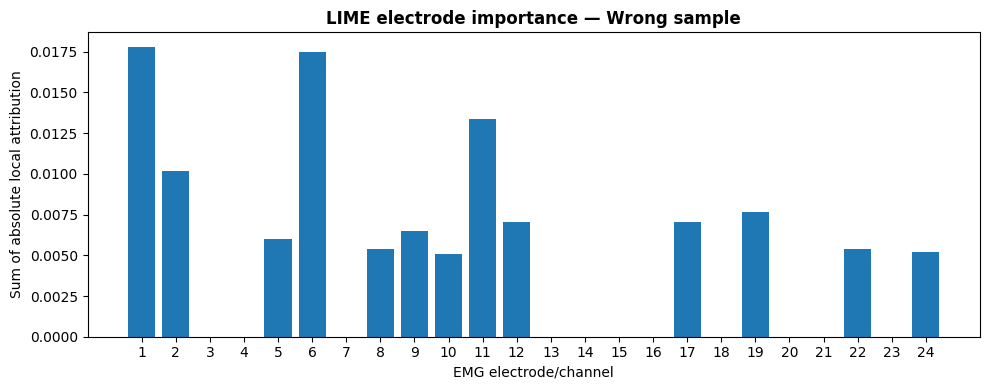

In [13]:
plot_top_attributions(
    lime_correct_df,
    f"LIME — Correct sample | predicted {GESTURE_NAMES[int(correct_record['pred_label'])]}",
    "lime_correct_top_features.png",
)
plot_top_attributions(
    lime_wrong_df,
    (
        f"LIME — Wrong sample | true {GESTURE_NAMES[int(wrong_record['true_label'])]} "
        f"→ predicted {GESTURE_NAMES[int(wrong_record['pred_label'])]}"
    ),
    "lime_wrong_top_features.png",
)

plot_electrode_importance(
    lime_correct_df,
    "LIME electrode importance — Correct sample",
    "lime_correct_electrodes.png",
)
plot_electrode_importance(
    lime_wrong_df,
    "LIME electrode importance — Wrong sample",
    "lime_wrong_electrodes.png",
)

# Combined Interpretation

## Section 14 — Aggregate SHAP and LIME by electrode and feature type

Absolute attribution is used for ranking importance. Signed values in the feature-level tables should be used when discussing whether a feature supported or opposed the predicted class locally.

In [14]:
all_attr_df = pd.concat(
    [shap_all_df, lime_all_df],
    ignore_index=True,
)

electrode_summary = (
    all_attr_df
    .groupby(["Case", "Method", "Electrode"], as_index=False)["Absolute attribution"]
    .sum()
    .sort_values(
        ["Case", "Method", "Absolute attribution"],
        ascending=[True, True, False],
    )
)

metric_summary = (
    all_attr_df
    .groupby(["Case", "Method", "Metric"], as_index=False)["Absolute attribution"]
    .sum()
    .sort_values(
        ["Case", "Method", "Absolute attribution"],
        ascending=[True, True, False],
    )
)

electrode_summary.to_csv(
    OUTPUT_FOLDER / "xai_electrode_summary.csv",
    index=False,
)
metric_summary.to_csv(
    OUTPUT_FOLDER / "xai_metric_summary.csv",
    index=False,
)

print("Top electrodes by local importance:")
display(
    electrode_summary
    .groupby(["Case", "Method"], group_keys=False)
    .head(5)
)

print("\nFeature-type importance:")
display(metric_summary)

Top electrodes by local importance:


,Case,Method,Electrode,Absolute attribution
17,Correct,LIME,18,0.012668
4,Correct,LIME,5,0.008903
21,Correct,LIME,22,0.008876
13,Correct,LIME,14,0.008778
12,Correct,LIME,13,0.007941
45,Correct,SHAP,22,0.271300
33,Correct,SHAP,10,0.177407
36,Correct,SHAP,13,0.138296
43,Correct,SHAP,20,0.108424
34,Correct,SHAP,11,0.101482



Feature-type importance:


,Case,Method,Metric,Absolute attribution
0,Correct,LIME,MAV,0.018320
5,Correct,LIME,WL,0.018182
2,Correct,LIME,SSC,0.017528
1,Correct,LIME,RMS,0.012722
4,Correct,LIME,VAR,0.012577
3,Correct,LIME,STD,0.007667
6,Correct,LIME,ZC,0.000000
12,Correct,SHAP,WL,0.793725
10,Correct,SHAP,STD,0.375985
7,Correct,SHAP,MAV,0.122765


## Section 15 — Report-ready comparison of the correct and wrong cases

For the wrong sample, SHAP and LIME explain **why the model favored the incorrect predicted class**, which is the relevant failure-mode explanation.  
Do not interpret these local attributions as proof that an electrode or feature causes a gesture.

In [15]:
def top_items(df, column, n=5):
    grouped = (
        df.groupby(column, as_index=False)["Absolute attribution"]
        .sum()
        .sort_values("Absolute attribution", ascending=False)
        .head(n)
    )
    return grouped[column].tolist()


report_rows = []
for case_name, true_record, shap_df, lime_df in [
    ("Correct", correct_record, shap_correct_df, lime_correct_df),
    ("Wrong", wrong_record, shap_wrong_df, lime_wrong_df),
]:
    report_rows.append({
        "Case": case_name,
        "True class": GESTURE_NAMES[int(true_record["true_label"])],
        "Predicted class": GESTURE_NAMES[int(true_record["pred_label"])],
        "Confidence": float(true_record["prediction_confidence"]),
        "SHAP top features": ", ".join(
            shap_df.sort_values("Absolute attribution", ascending=False)
            .head(5)["Feature"]
            .tolist()
        ),
        "LIME top features": ", ".join(
            lime_df.sort_values("Absolute attribution", ascending=False)
            .head(5)["Feature"]
            .tolist()
        ),
        "SHAP top electrodes": ", ".join(
            f"EMG_{x}" for x in top_items(shap_df, "Electrode", 5)
        ),
        "LIME top electrodes": ", ".join(
            f"EMG_{x}" for x in top_items(lime_df, "Electrode", 5)
        ),
    })

report_summary_df = pd.DataFrame(report_rows)
display(report_summary_df)

report_summary_df.to_csv(
    OUTPUT_FOLDER / "xai_report_summary.csv",
    index=False,
)

,Case,True class,Predicted class,Confidence,SHAP top features,LIME top features,SHAP top electrodes,LIME top electrodes
0,Correct,Pinch-Ring,Pinch-Ring,0.919520,"EMG_22_WL, EMG_13_WL, EMG_10_STD, EMG_20_WL, E...","EMG_18_WL, EMG_11_MAV, EMG_2_WL, EMG_14_RMS, E...","EMG_22, EMG_10, EMG_13, EMG_20, EMG_11","EMG_18, EMG_5, EMG_22, EMG_14, EMG_13"
1,Wrong,Flexion,Fist,0.571337,"EMG_14_WL, EMG_6_WL, EMG_3_WL, EMG_21_WL, EMG_...","EMG_11_ZC, EMG_17_VAR, EMG_6_SSC, EMG_12_ZC, E...","EMG_14, EMG_6, EMG_3, EMG_5, EMG_19","EMG_1, EMG_6, EMG_11, EMG_2, EMG_19"


## Section 16 — Save final XAI summary

These files are the main evidence to use in the Task-3 report:

- `selected_xai_samples.csv`
- `shap_feature_attributions.csv`
- `lime_feature_attributions.csv`
- `xai_electrode_summary.csv`
- `xai_metric_summary.csv`
- `xai_report_summary.csv`
- SHAP/LIME PNG figures
- `xai_summary.json`

In [16]:
def top_feature_records(df, n=10):
    return (
        df.sort_values("Absolute attribution", ascending=False)
        .head(n)[
            [
                "Feature",
                "Electrode",
                "Metric",
                "Attribution",
                "Absolute attribution",
            ]
        ]
        .to_dict("records")
    )

xai_summary = {
    "model_config": final_config,
    "selection_rule": (
        "Within correct and incorrect held-out test predictions separately, "
        "select the sample closest to the median prediction confidence."
    ),
    "background_policy": (
        "SHAP and LIME reference distributions use only original Task-2 "
        "training-subject windows."
    ),
    "correct_sample": {
        "row_index_in_test_df": correct_row,
        "subject_id": int(correct_record["subject_id"]),
        "true_label": int(correct_record["true_label"]),
        "true_class": GESTURE_NAMES[int(correct_record["true_label"])],
        "pred_label": int(correct_record["pred_label"]),
        "pred_class": GESTURE_NAMES[int(correct_record["pred_label"])],
        "confidence": float(correct_record["prediction_confidence"]),
        "shap_top_features": top_feature_records(shap_correct_df),
        "lime_top_features": top_feature_records(lime_correct_df),
    },
    "wrong_sample": {
        "row_index_in_test_df": wrong_row,
        "subject_id": int(wrong_record["subject_id"]),
        "true_label": int(wrong_record["true_label"]),
        "true_class": GESTURE_NAMES[int(wrong_record["true_label"])],
        "pred_label": int(wrong_record["pred_label"]),
        "pred_class": GESTURE_NAMES[int(wrong_record["pred_label"])],
        "confidence": float(wrong_record["prediction_confidence"]),
        "shap_top_features": top_feature_records(shap_wrong_df),
        "lime_top_features": top_feature_records(lime_wrong_df),
    },
}

with open(OUTPUT_FOLDER / "xai_summary.json", "w") as f:
    json.dump(
        xai_summary,
        f,
        indent=2,
        default=lambda o: o.item() if hasattr(o, "item") else str(o),
    )

print("Task-3 explainability notebook complete.")
print(f"Saved XAI outputs -> {OUTPUT_FOLDER}")
print("\nNo model training or model-selection changes were made in this notebook.")

Task-3 explainability notebook complete.
Saved XAI outputs -> /kaggle/working/task3_xai_results

No model training or model-selection changes were made in this notebook.
